## XAI — SHAP analýza interpretovateľnosti modelov

Notebook vizualizuje dôležitosť príznakov pre všetky tri modely pomocou knižnice SHAP:

- **Summary bar plot** — globálna dôležitosť príznakov (priemerný absolútny SHAP )
- **Summary dot plot** — smer vplyvu príznakov (pozitívny/negatívny)
- **Waterfall plot** — lokálne vysvetlenie konkrétneho záznamu

Načítava natrénované modely zo súborov `models/`.

> **Pred spustením** je potrebné mať natrénované všetky tri modely.

/var/folders/js/brf3r1893px2tvbbg9dj27zr0000gn/T/ipykernel_18493/3045392988.py:160: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals1, X_sample1,
/var/folders/js/brf3r1893px2tvbbg9dj27zr0000gn/T/ipykernel_18493/3045392988.py:167: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals1, X_sample1,


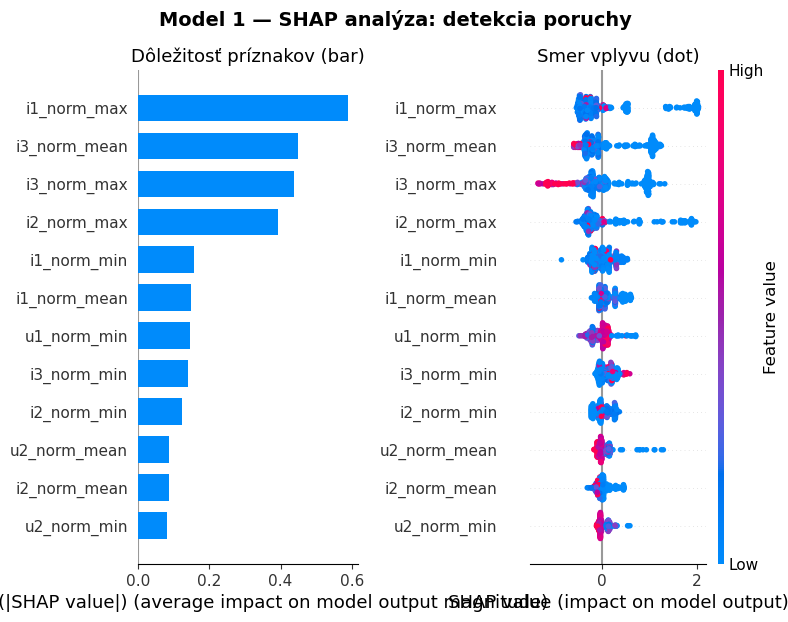

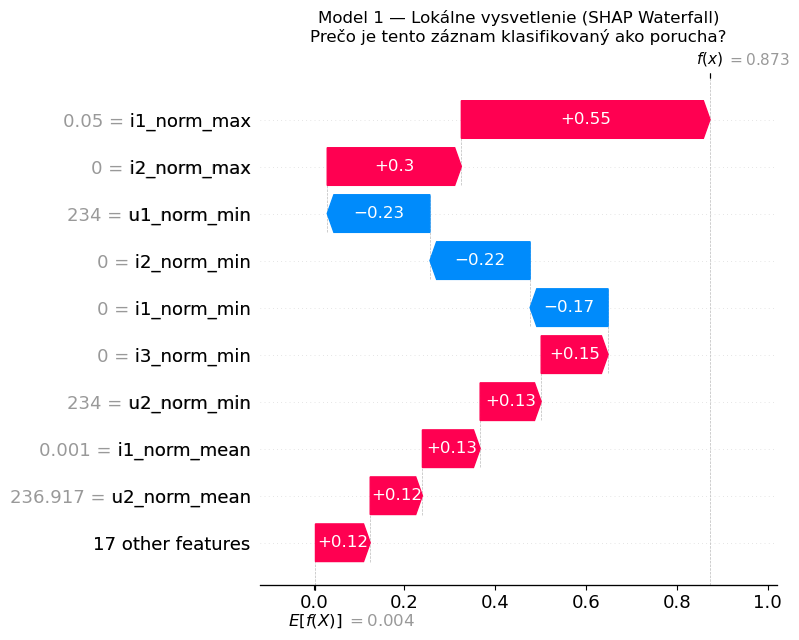

/var/folders/js/brf3r1893px2tvbbg9dj27zr0000gn/T/ipykernel_18493/3045392988.py:214: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals2, X_sample2,
/var/folders/js/brf3r1893px2tvbbg9dj27zr0000gn/T/ipykernel_18493/3045392988.py:221: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals2, X_sample2,


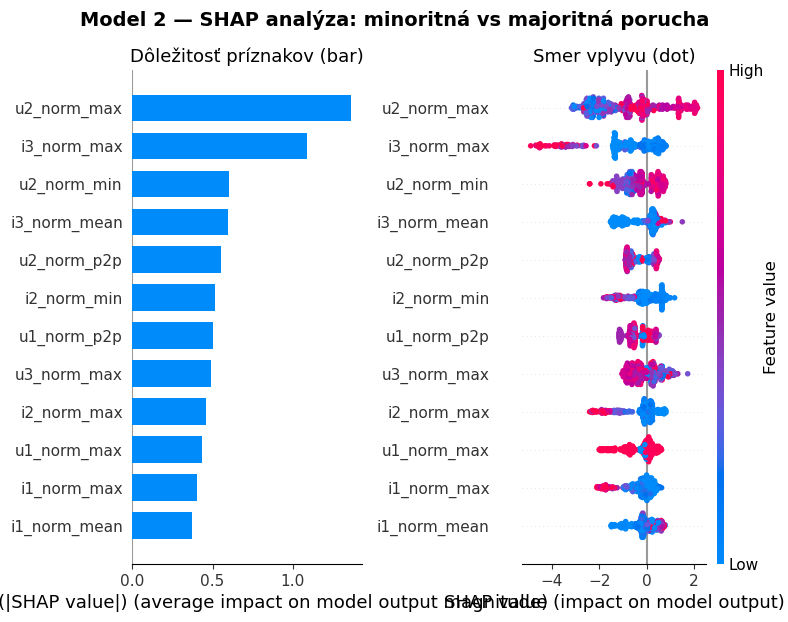

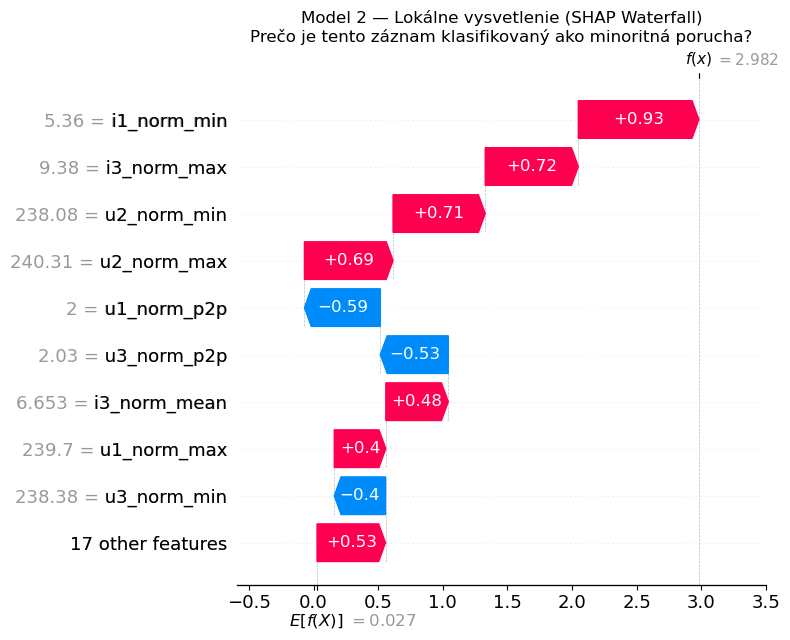

/var/folders/js/brf3r1893px2tvbbg9dj27zr0000gn/T/ipykernel_18493/3045392988.py:277: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/var/folders/js/brf3r1893px2tvbbg9dj27zr0000gn/T/ipykernel_18493/3045392988.py:277: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


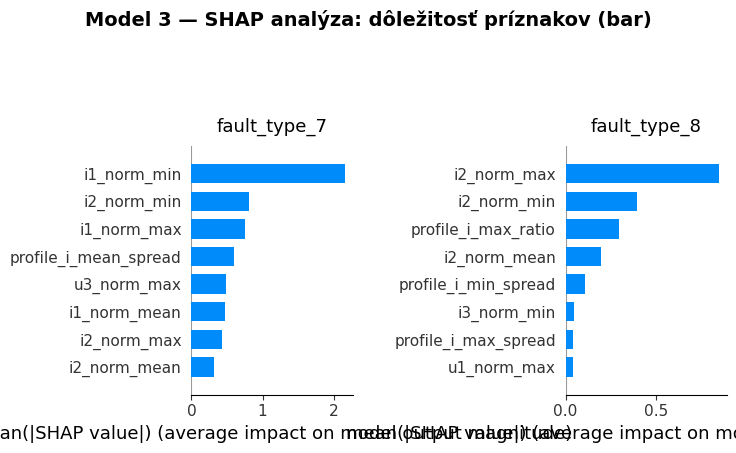

/var/folders/js/brf3r1893px2tvbbg9dj27zr0000gn/T/ipykernel_18493/3045392988.py:277: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/var/folders/js/brf3r1893px2tvbbg9dj27zr0000gn/T/ipykernel_18493/3045392988.py:277: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


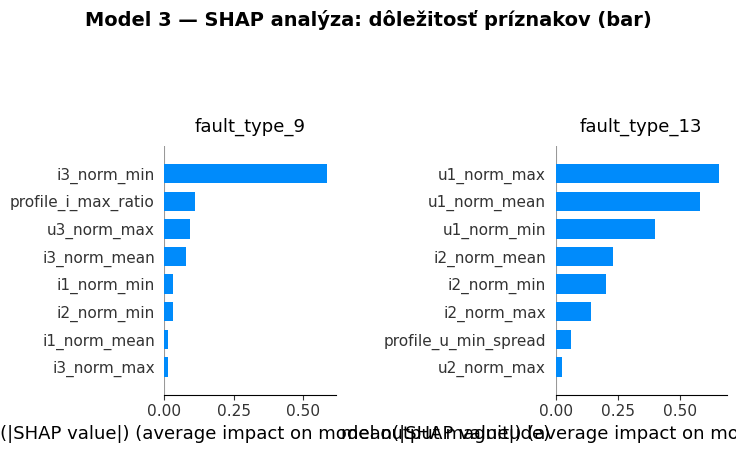

In [2]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import os
from collections import defaultdict

np.random.seed(42)

# Шляхи до файлів
DATA_PATH  = 'data/final_typy.csv'
MODELS_DIR = 'models'

# Načítanie a zoradenie dát
df = pd.read_csv(DATA_PATH)
df['t_utc'] = pd.to_datetime(df['t_utc'])
df_sorted = df.sort_values(['eic', 't_utc']).reset_index(drop=True)

fault_cols = [c for c in df_sorted.columns if c.startswith('fault_type')]

# Rozdelenie podľa EIC — rovnaký kód ako v modeloch
eic_fault_profile = {}
for eic in sorted(df_sorted['eic'].unique()):
    eic_data = df_sorted[df_sorted['eic'] == eic]
    profile  = tuple(int(eic_data[col].sum() > 0) for col in sorted(fault_cols))
    eic_fault_profile[eic] = profile

profile_groups = defaultdict(list)
for eic, profile in eic_fault_profile.items():
    profile_groups[profile].append(eic)

np.random.seed(42)
train_eics, test_eics = [], []

for profile, eics in sorted(profile_groups.items()):
    eics_shuffled = eics.copy()
    np.random.shuffle(eics_shuffled)
    if len(eics_shuffled) == 1:
        train_eics.extend(eics_shuffled)
    elif len(eics_shuffled) == 2:
        train_eics.append(eics_shuffled[0])
        test_eics.append(eics_shuffled[1])
    else:
        split_n = max(1, int(len(eics_shuffled) * 0.8))
        train_eics.extend(eics_shuffled[:split_n])
        test_eics.extend(eics_shuffled[split_n:])

train_eics = set(train_eics)
test_eics  = set(test_eics)

train_df = df_sorted[df_sorted['eic'].isin(train_eics)].copy()
test_df  = df_sorted[df_sorted['eic'].isin(test_eics)].copy()

# Definícia príznakov
feature_cols = [
    'i1_norm_max', 'i1_norm_mean', 'i1_norm_min',
    'i2_norm_max', 'i2_norm_mean', 'i2_norm_min',
    'i3_norm_max', 'i3_norm_mean', 'i3_norm_min',
    'u1_norm_min', 'u1_norm_max', 'u1_norm_mean',
    'u2_norm_min', 'u2_norm_max', 'u2_norm_mean',
    'u3_norm_min', 'u3_norm_max', 'u3_norm_mean',
    'u1_norm_p2p', 'u1_norm_std', 'u1_norm_mean_abs_diff',
    'u2_norm_p2p', 'u2_norm_mean_abs_diff',
    'u3_norm_p2p', 'u3_norm_mean_abs_diff',
    'u1_norm_kurtosis',
]

MINORITY_COLS = [
    'fault_type_7',
    'fault_type_8',
    'fault_type_9',
    'fault_type_13',
]

def add_fault_profile_features(df):
    """
    Výpočet profilových príznakov zo surových signálov.
    Zachytáva medzifázové rozdiely a celkové charakteristiky signálov.
    """
    df  = df.copy()
    eps = 1e-6

    i_max_cols  = ['i1_norm_max',  'i2_norm_max',  'i3_norm_max']
    i_mean_cols = ['i1_norm_mean', 'i2_norm_mean', 'i3_norm_mean']
    i_min_cols  = ['i1_norm_min',  'i2_norm_min',  'i3_norm_min']
    u_max_cols  = ['u1_norm_max',  'u2_norm_max',  'u3_norm_max']
    u_mean_cols = ['u1_norm_mean', 'u2_norm_mean', 'u3_norm_mean']
    u_min_cols  = ['u1_norm_min',  'u2_norm_min',  'u3_norm_min']
    u_p2p_cols  = ['u1_norm_p2p',  'u2_norm_p2p',  'u3_norm_p2p']
    u_mad_cols  = ['u1_norm_mean_abs_diff', 'u2_norm_mean_abs_diff', 'u3_norm_mean_abs_diff']

    df['profile_i_max_spread']  = df[i_max_cols].max(axis=1)  - df[i_max_cols].min(axis=1)
    df['profile_i_mean_spread'] = df[i_mean_cols].max(axis=1) - df[i_mean_cols].min(axis=1)
    df['profile_i_min_spread']  = df[i_min_cols].max(axis=1)  - df[i_min_cols].min(axis=1)
    df['profile_u_max_spread']  = df[u_max_cols].max(axis=1)  - df[u_max_cols].min(axis=1)
    df['profile_u_mean_spread'] = df[u_mean_cols].max(axis=1) - df[u_mean_cols].min(axis=1)
    df['profile_u_min_spread']  = df[u_min_cols].max(axis=1)  - df[u_min_cols].min(axis=1)
    df['profile_i_mean_total']  = df[i_mean_cols].mean(axis=1)
    df['profile_u_mean_total']  = df[u_mean_cols].mean(axis=1)
    df['profile_i_max_ratio']   = df[i_max_cols].max(axis=1) / (df[i_max_cols].min(axis=1).abs() + eps)
    df['profile_u_max_ratio']   = df[u_max_cols].max(axis=1) / (df[u_max_cols].min(axis=1).abs() + eps)
    df['profile_u_p2p_mean']    = df[u_p2p_cols].mean(axis=1)
    df['profile_u_p2p_spread']  = df[u_p2p_cols].max(axis=1) - df[u_p2p_cols].min(axis=1)
    df['profile_u_mad_mean']    = df[u_mad_cols].mean(axis=1)
    df['profile_u_mad_spread']  = df[u_mad_cols].max(axis=1) - df[u_mad_cols].min(axis=1)

    return df

# Príprava dát pre každý model
train_medians_model1 = train_df[feature_cols].median()
X_test  = test_df[feature_cols].fillna(train_medians_model1)
y_test  = test_df['porucha?'].astype(int)

train2               = train_df[train_df['porucha?'] == 1].copy()
train_medians_model2 = train2[feature_cols].median()
test2                = test_df[test_df['porucha?'] == 1].copy()
test2['minor_fault?'] = (test2[MINORITY_COLS].sum(axis=1) > 0).astype(int)
X2_test  = test2[feature_cols].fillna(train_medians_model2)
y2_test  = test2['minor_fault?'].astype(int)

train3               = train_df[train_df[MINORITY_COLS].max(axis=1) == 1].copy()
train3               = add_fault_profile_features(train3)
profile_cols         = [c for c in train3.columns if c.startswith('profile_')]
feature_cols_model3  = feature_cols + profile_cols
train_medians_model3 = train3[feature_cols_model3].median()
test3                = test_df[test_df[MINORITY_COLS].max(axis=1) == 1].copy()
test3                = add_fault_profile_features(test3)
X3_test  = test3[feature_cols_model3].fillna(train_medians_model3)

# Načítanie natrenovaných modelov zo súborov
model1        = joblib.load(f'{MODELS_DIR}/model1.pkl')
model2        = joblib.load(f'{MODELS_DIR}/model2.pkl')
model3_models = joblib.load(f'{MODELS_DIR}/model3_models.pkl')

# Prahové hodnoty
THRESHOLD  = 0.7   # Model 1
THRESHOLD2 = 0.25  # Model 2

feature_cols_model1 = feature_cols
feature_cols_model2 = feature_cols
trained_labels      = list(model3_models.keys())

def fix_shap_fontsize(ax, fontsize=11):
    for label in ax.get_yticklabels():
        label.set_fontsize(fontsize)
    for label in ax.get_xticklabels():
        label.set_fontsize(fontsize)
    ax.title.set_fontsize(13)

# SHAP analýza — Model 1
explainer1  = shap.TreeExplainer(model1)
sample_idx1 = np.random.choice(len(X_test), size=500, replace=False)
X_sample1   = X_test.iloc[sample_idx1]
shap_vals1  = explainer1.shap_values(X_sample1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_vals1, X_sample1,
    feature_names=feature_cols_model1,
    max_display=12, plot_type='bar', show=False)
axes[0].set_title("Dôležitosť príznakov (bar)", fontsize=12)
fix_shap_fontsize(axes[0])

plt.sca(axes[1])
shap.summary_plot(shap_vals1, X_sample1,
    feature_names=feature_cols_model1,
    max_display=12, plot_type='dot', show=False)
axes[1].set_title("Smer vplyvu (dot)", fontsize=12)
fix_shap_fontsize(axes[1])

fig.suptitle("Model 1 — SHAP analýza: detekcia poruchy",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Waterfall — Model 1
correct_idx1 = np.where(
    (model1.predict_proba(X_sample1)[:, 1] >= THRESHOLD) &
    (y_test.iloc[sample_idx1].values == 1)
)[0]

if len(correct_idx1) > 0:
    idx1 = correct_idx1[0]
    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals1[idx1],
            base_values=explainer1.expected_value,
            data=X_sample1.iloc[idx1],
            feature_names=feature_cols_model1
        ),
        show=False
    )
    fix_shap_fontsize(plt.gca())
    plt.title("Model 1 — Lokálne vysvetlenie (SHAP Waterfall)\n"
              "Prečo je tento záznam klasifikovaný ako porucha?",
              fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Model 1: žiadny správny záznam pre Waterfall")

# SHAP analýza — Model 2
explainer2  = shap.TreeExplainer(model2)
sample_idx2 = np.random.choice(len(X2_test), size=500, replace=False)
X_sample2   = X2_test.iloc[sample_idx2]
shap_vals2  = explainer2.shap_values(X_sample2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_vals2, X_sample2,
    feature_names=feature_cols_model2,
    max_display=12, plot_type='bar', show=False)
axes[0].set_title("Dôležitosť príznakov (bar)", fontsize=12)
fix_shap_fontsize(axes[0])

plt.sca(axes[1])
shap.summary_plot(shap_vals2, X_sample2,
    feature_names=feature_cols_model2,
    max_display=12, plot_type='dot', show=False)
axes[1].set_title("Smer vplyvu (dot)", fontsize=12)
fix_shap_fontsize(axes[1])

fig.suptitle("Model 2 — SHAP analýza: minoritná vs majoritná porucha",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Waterfall — Model 2
correct_idx2 = np.where(
    (model2.predict_proba(X_sample2)[:, 1] >= THRESHOLD2) &
    (y2_test.iloc[sample_idx2].values == 1)
)[0]

if len(correct_idx2) > 0:
    idx2 = correct_idx2[0]
    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals2[idx2],
            base_values=explainer2.expected_value,
            data=X_sample2.iloc[idx2],
            feature_names=feature_cols_model2
        ),
        show=False
    )
    fix_shap_fontsize(plt.gca())
    plt.title("Model 2 — Lokálne vysvetlenie (SHAP Waterfall)\n"
              "Prečo je tento záznam klasifikovaný ako minoritná porucha?",
              fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Model 2: žiadny správny záznam pre Waterfall")

# SHAP analýza — Model 3
sample_idx3 = np.random.choice(len(X3_test), size=300, replace=False)
X_sample3   = X3_test.iloc[sample_idx3]

shap_vals3_all = {}
for label in trained_labels:
    explainer3            = shap.TreeExplainer(model3_models[label])
    shap_vals3_all[label] = explainer3.shap_values(X_sample3)

# Bar plots — Model 3
labels_part1 = trained_labels[:2]
labels_part2 = trained_labels[2:]

for part, labels_part in enumerate([labels_part1, labels_part2], start=1):
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    for i, label in enumerate(labels_part):
        plt.sca(axes[i])
        shap.summary_plot(
            shap_vals3_all[label], X_sample3,
            feature_names=feature_cols_model3,
            max_display=8, plot_type='bar', show=False)
        axes[i].set_title(label, fontsize=13, pad=10)
        fix_shap_fontsize(axes[i])

    fig.suptitle("Model 3 — SHAP analýza: dôležitosť príznakov (bar)",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(pad=3.0)
    plt.show()